In [2]:
import ollama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Prueba de conexión
respuesta = ollama.chat(model='mistral', messages=[
    {'role': 'user', 'content': '¿Cuánto es 2+2? Responde solo el número.'}
])
print(respuesta['message']['content'])

 4


In [3]:
train = df[df.index < '2025-07-13']['precio_bolsa']
test = df[df.index >= '2025-07-13']['precio_bolsa']

def serie_a_texto(serie, decimales=1):
    """Convierte una serie de precios a texto separado por comas."""
    return ', '.join([str(round(v, decimales)) for v in serie])

def predecir_llm(serie_historica, pasos=7, ventana=60):
    """Usa el LLM para predecir los siguientes N valores."""
    
    # Tomamos los últimos `ventana` días como contexto
    contexto = serie_historica[-ventana:]
    texto_serie = serie_a_texto(contexto)
    
    prompt = f"""Eres un experto en series de tiempo de precios de energía eléctrica en Colombia.
A continuación tienes los últimos {ventana} días del precio de bolsa en COP/kWh:

{texto_serie}

Continúa la serie prediciendo los siguientes {pasos} valores. 
Responde ÚNICAMENTE con los {pasos} números separados por comas, sin texto adicional.
Los valores deben ser coherentes con la tendencia y el rango de la serie."""

    respuesta = ollama.chat(model='mistral', messages=[
        {'role': 'user', 'content': prompt}
    ])
    
    return respuesta['message']['content']

# Prueba con los primeros 7 días del test
resultado = predecir_llm(train, pasos=7)
print("Predicción LLM:")
print(resultado)

Predicción LLM:
 Predicción de precios:
130.0, 145.2, 160.7, 180.9, 155.4, 128.0, 112.5


In [7]:
def parsear_prediccion(texto, pasos, rango_valido):
    """Extrae los números de la respuesta del LLM, descartando cualquier
    valor fuera de un rango de precio plausible ANTES de recortar a `pasos`.

    Fix vs. la versión anterior: si el modelo repite el número de pasos
    pedidos dentro de la respuesta (p. ej. el "7" de "siguientes 7 valores"),
    ese valor se filtra antes de tomar los primeros `pasos` números, no
    después. Así no se pierde la última predicción real ni se desalinean
    las fechas (el bug que teníamos: comparar la predicción del día 1
    contra el precio real del día 2, etc.)."""
    import re
    numeros = re.findall(r'-?\d+\.?\d*', texto)
    candidatos = [float(n) for n in numeros]
    minimo, maximo = rango_valido
    validos = [v for v in candidatos if minimo <= v <= maximo]
    return validos[:pasos]


# Rango de precio plausible para filtrar artefactos de parseo (más laxo que
# el rango histórico real, para no descartar predicciones válidas del
# modelo aunque se salgan del rango que ha visto en el pasado)
RANGO_VALIDO = (train.min() * 0.3, train.max() * 2.5)
print(f"Rango válido para filtrar: {RANGO_VALIDO[0]:.1f} - {RANGO_VALIDO[1]:.1f}")

PASOS = 7
predicciones_llm = []
fechas_pred = []
bloques_descartados = 0

serie_actual = train.copy()

for i in range(0, len(test), PASOS):
    pasos_bloque = min(PASOS, len(test) - i)  # el último bloque puede ser más corto
    texto = predecir_llm(serie_actual, pasos=pasos_bloque)
    valores = parsear_prediccion(texto, pasos_bloque, RANGO_VALIDO)

    if len(valores) == pasos_bloque:
        predicciones_llm.extend(valores)
        fechas_pred.extend(test.index[i:i + pasos_bloque])
    else:
        bloques_descartados += 1
        print(f"  [descartado] Bloque {i // PASOS + 1}: se esperaban {pasos_bloque} valores válidos, se obtuvieron {len(valores)}")

    # Walk-forward: se actualiza con los valores reales del test, sin importar
    # si el bloque se pudo parsear o no
    serie_actual = pd.concat([serie_actual, test.iloc[i:i + pasos_bloque]])

    print(f"Bloque {i // PASOS + 1}: {valores}")

print(f"\nTotal predicciones válidas: {len(predicciones_llm)} de {len(test)} días de test")
print(f"Bloques descartados por parseo: {bloques_descartados}")

Rango válido para filtrar: 17.0 - 6247.0
Bloque 1: [160.0, 150.0, 140.0, 130.0, 120.0, 140.0, 170.0]
Bloque 2: [146.0, 125.0, 110.0, 130.0, 140.0, 150.0, 170.0]
Bloque 3: [190.0, 200.0, 185.0, 160.0, 140.0, 130.0, 150.0]
Bloque 4: [190.0, 200.0, 220.0, 235.0, 245.0, 260.0, 275.0]
Bloque 5: [190.0, 220.0, 240.0, 250.0, 260.0, 280.0, 300.0]
Bloque 6: [180.0, 235.0, 260.0, 290.0, 320.0, 340.0, 370.0]
Bloque 7: [315.9, 280.0, 240.0, 220.0, 260.0, 280.0, 320.0]
Bloque 8: [380.0, 425.0, 460.0, 490.0, 510.0, 530.0, 550.0]
Bloque 9: [250.0, 350.0, 400.0, 450.0, 500.0, 600.0, 700.0]
Bloque 10: [350.0, 420.0, 480.0, 510.0, 600.0, 700.0, 800.0]
Bloque 11: [310.4, 350.0, 420.5, 480.0, 550.0, 650.0, 700.0]
Bloque 12: [351.0, 428.5, 514.1, 600.0, 700.0, 800.0, 900.0]
Bloque 13: [500.0, 525.6, 550.3, 600.0, 650.1, 700.0, 750.0]
Bloque 14: [150.0, 200.5, 280.3, 345.6, 450.1, 500.0, 350.7]
Bloque 15: [200.5, 185.3, 220.9, 256.7, 300.4, 340.2, 380.6]
Bloque 16: [180.0, 165.0, 140.0, 125.0, 135.0, 150.0,

In [8]:
pred_array = np.array(predicciones_llm)
fechas_array = pd.DatetimeIndex(fechas_pred)

real_llm = test.loc[fechas_array].values

mae_llm = np.mean(np.abs(real_llm - pred_array))
rmse_llm = np.sqrt(np.mean((real_llm - pred_array) ** 2))
mape_llm = np.mean(np.abs((real_llm - pred_array) / real_llm)) * 100

print(f"MAE:  {mae_llm:.2f} $/kWh")
print(f"RMSE: {rmse_llm:.2f} $/kWh")
print(f"MAPE: {mape_llm:.2f}%")
print(f"Días evaluados: {len(pred_array)} de {len(test)}")

MAE:  119.70 $/kWh
RMSE: 167.76 $/kWh
MAPE: 58.01%
Días evaluados: 293 de 293


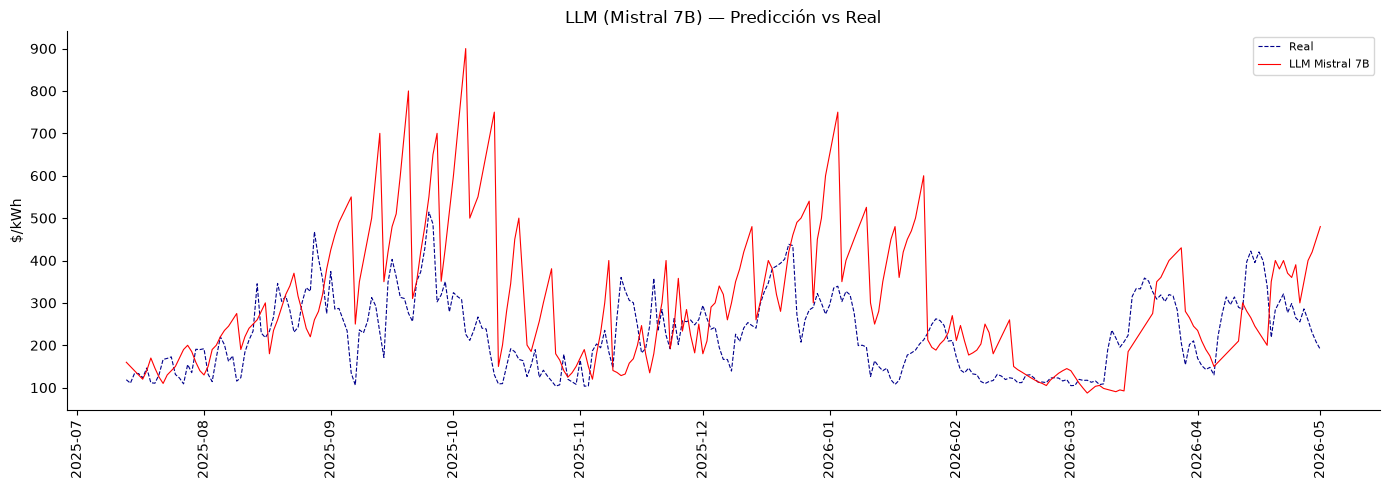

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index[:len(real_llm)], real_llm, color='darkblue', 
        linewidth=0.8, linestyle='--', label='Real')
ax.plot(fechas_array, pred_array, color='red', 
        linewidth=0.8, label='LLM Mistral 7B')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LLM (Mistral 7B) — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()